In [10]:
PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"

### Behaviour Check


In [11]:
import pandas as pd
import os
import numpy as np

loc = []
identity = [] 
beh_data_overall = []
for sub in [0,1,2,3,4,5]:
    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "beh", folder_name)
    files = os.listdir(sub_folder)

    csvs = [x for x in files if ".csv" in x]
    beh_data = []

    for csv in csvs:
        csv_file =os.path.join(sub_folder, csv)
        beh_data.append(pd.read_csv(csv_file))
        
    beh_data = pd.concat(beh_data).reset_index(drop=True)

    # substitute all None with np.nan
    beh_data = beh_data.replace(["None", "none", ""], np.nan)

    # convert boolean accuracy to numeric
    beh_data["correct_loc"] = beh_data["correct_loc"].astype(float)
    beh_data["correct_id"]  = beh_data["correct_id"].astype(float)
    beh_data_overall.append(beh_data)
    loc.append(beh_data["correct_loc"].values)
    identity.append(beh_data[beh_data["identity_catch"] == True]["correct_id"].values)

beh_data = pd.concat(beh_data_overall).reset_index(drop=True)
beh_data["rt_loc_log"] = np.log(beh_data["rt_loc"])

/home/boyanova/miniconda3/envs/decoding_env/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


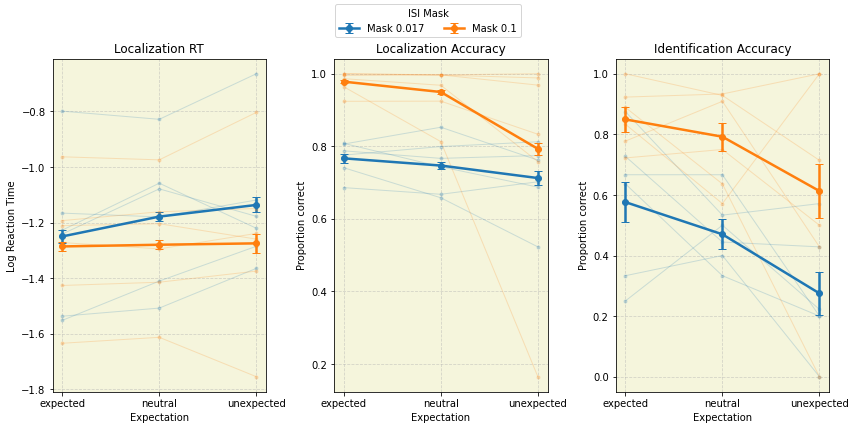

In [5]:
import matplotlib.pyplot as plt

def plot_interaction(ax, df, dv, ylabel):
    expectations = ['expected', 'neutral', 'unexpected']  # fixed order
    masks = sorted(df["isi_mask"].unique())
    colors = ['#1f77b4', '#ff7f0e']  # blue, orange

    x = np.arange(len(expectations))
    lines = []

    for i, mask in enumerate(masks):
        subset = df[df["isi_mask"] == mask]
        color = colors[i]

        # ── individual participant lines (thin, transparent) ──
        for participant in subset["participant"].unique():
            p_data = (
                subset[subset["participant"] == participant]
                .groupby("expectation")[dv]
                .mean()
                .reindex(expectations)
            )
            ax.plot(x, p_data, color=color, alpha=0.2, linewidth=1,
                    marker='o', markersize=3)

        # ── group mean + SEM (thick, solid) ──
        means = subset.groupby("expectation")[dv].mean().reindex(expectations)
        ses   = subset.groupby("expectation")[dv].sem().reindex(expectations)

        line = ax.errorbar(
            x, means, yerr=ses,
            marker="o", capsize=4, linewidth=2.5, markersize=6,
            color=color, label=f"Mask {mask}"
        )
        lines.append(line)

    ax.set_xticks(x)
    ax.set_xticklabels(expectations)
    ax.set_xlabel("Expectation")
    ax.set_ylabel(ylabel)
    ax.patch.set_facecolor("#f5f5dc")

    return lines


fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True)

lines = plot_interaction(axes[0], beh_data, "rt_loc_log", "Log Reaction Time")
axes[0].set_title("Localization RT")
axes[0].grid(linestyle="--", alpha=0.5)

plot_interaction(axes[1], beh_data, "correct_loc", "Proportion correct")
axes[1].set_title("Localization Accuracy")
axes[1].grid(linestyle="--", alpha=0.5)

plot_interaction(axes[2], beh_data[beh_data.identity_catch == True], "correct_id", "Proportion correct")
axes[2].set_title("Identification Accuracy")
axes[2].grid(linestyle="--", alpha=0.5)

labels = [l.get_label() for l in lines]
fig.legend(lines, labels, title="ISI Mask", loc="upper center", ncol=len(labels))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [66]:
from scipy import stats

# ── Step 1: aggregate to participant means (match what your plots show) ──
cell_means = (
    beh_data
    .groupby(['participant', 'isi_mask', 'expectation'], observed=True)
    .agg(
        rt_loc    = ('rt_loc_log',     'mean'),
        acc_loc   = ('correct_loc','mean'),
        acc_id    = ('correct_id', 'mean'),   # adjust column name if different
    )
    .reset_index()
)

print(cell_means.head(12))
print("\nParticipants:", cell_means['participant'].nunique())
print("Cells per participant:", cell_means.groupby('participant').size().unique())

    participant  isi_mask expectation    rt_loc   acc_loc    acc_id
0             0     0.017    expected -1.551620  0.806283  0.666667
1             0     0.017     neutral -1.410286  0.852632  0.666667
2             0     0.017  unexpected -1.285075  0.761905  0.200000
3             0     0.100    expected -1.426062  1.000000  0.777778
4             0     0.100     neutral -1.414369  0.996479  0.909091
5             0     0.100  unexpected -1.374305  0.988636  0.428571
6             1     0.017    expected -1.536620  0.787500  0.727273
7             1     0.017     neutral -1.507437  0.766764  0.444444
8             1     0.017  unexpected -1.364570  0.774510  0.428571
9             1     0.100    expected -1.633950  1.000000  0.923077
10            1     0.100     neutral -1.612575  0.997085  0.933333
11            1     0.100  unexpected -1.754132  1.000000  1.000000

Participants: 6
Cells per participant: [6]


In [67]:
from statsmodels.stats.anova import AnovaRM

for dv in ['rt_loc', 'acc_loc', 'acc_id']:
    print(f"\n{'='*55}")
    print(f"  rm-ANOVA: {dv}")
    print(f"{'='*55}")
    result = AnovaRM(
        data=cell_means,
        depvar=dv,
        subject='participant',
        within=['isi_mask', 'expectation']
    ).fit()
    print(result.summary())


  rm-ANOVA: rt_loc
                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
isi_mask              6.1780 1.0000  5.0000 0.0555
expectation           2.5290 2.0000 10.0000 0.1292
isi_mask:expectation  1.8319 2.0000 10.0000 0.2100


  rm-ANOVA: acc_loc
                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
isi_mask             25.1387 1.0000  5.0000 0.0041
expectation           2.4420 2.0000 10.0000 0.1369
isi_mask:expectation  2.1394 2.0000 10.0000 0.1685


  rm-ANOVA: acc_id
                      Anova
                     F Value Num DF  Den DF Pr > F
--------------------------------------------------
isi_mask             14.4167 1.0000  5.0000 0.0127
expectation           5.7363 2.0000 10.0000 0.0219
isi_mask:expectation  0.0932 2.0000 10.0000 0.9118



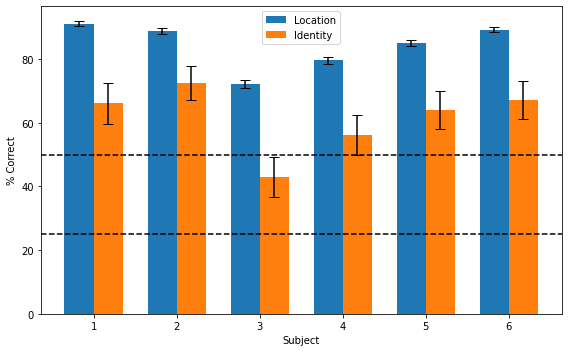

In [20]:
import matplotlib.pyplot as plt


loc = []
identity = []
for subject in [0,1,2,3,4,5]:
    loc.append(beh_data[beh_data.participant == subject].correct_loc.values)
    identity.append(beh_data[(beh_data.participant == subject) &
                             (beh_data.identity_catch == True)].correct_id.values)

loc_means = []
loc_se = []
id_means = []
id_se = []

for lc, ide in zip(loc, identity):
    # remove NaNs
    lc_valid = lc[~np.isnan(lc)] 
    ide_valid = ide[~np.isnan(ide)]

    loc_means.append(np.mean(lc_valid) * 100)
    id_means.append(np.mean(ide_valid) * 100)

    loc_se.append(np.std(lc_valid, ddof=1) / np.sqrt(len(lc_valid)) * 100)
    id_se.append(np.std(ide_valid, ddof=1) / np.sqrt(len(ide_valid)) * 100)

x = np.arange(len(loc_means))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, loc_means, width, yerr=loc_se, label='Location', capsize=5)
plt.bar(x + width/2, id_means, width, yerr=id_se, label='Identity', capsize=5)

plt.xlabel("Subject")
plt.ylabel("% Correct")
plt.xticks(x, np.arange(1, len(x)+1))  # subjects labeled 1..N
plt.legend()

plt.tight_layout()
plt.axhline(25, color="k", linestyle="--")
plt.axhline(50, color="k", linestyle="--")
plt.show()

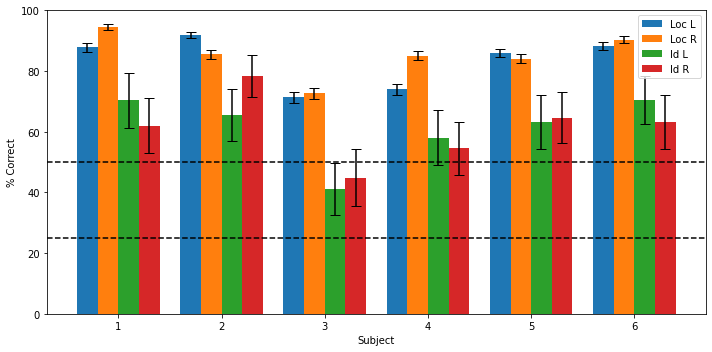

In [21]:
loc_L, loc_R = [], []
id_L, id_R = [], []

for subject in [0,1,2,3,4,5]:
    sub = beh_data[beh_data.participant == subject]

    loc_L.append(sub[sub.target_loc == 'L'].correct_loc.values)
    loc_R.append(sub[sub.target_loc == 'R'].correct_loc.values)

    id_L.append(sub[(sub.target_loc == 'L') & (sub.identity_catch == True)].correct_id.values)
    id_R.append(sub[(sub.target_loc == 'R') & (sub.identity_catch == True)].correct_id.values)
    
def compute_stats(arr_list):
    means, ses = [], []
    for arr in arr_list:
        valid = arr[~np.isnan(arr)]
        means.append(np.mean(valid) * 100)
        ses.append(np.std(valid, ddof=1) / np.sqrt(len(valid)) * 100)
    return means, ses

locL_mean, locL_se = compute_stats(loc_L)
locR_mean, locR_se = compute_stats(loc_R)
idL_mean, idL_se = compute_stats(id_L)
idR_mean, idR_se = compute_stats(id_R)

x = np.arange(len(locL_mean))
width = 0.2

plt.figure(figsize=(10,5))

plt.bar(x - 1.5*width, locL_mean, width, yerr=locL_se, label='Loc L', capsize=5)
plt.bar(x - 0.5*width, locR_mean, width, yerr=locR_se, label='Loc R', capsize=5)
plt.bar(x + 0.5*width, idL_mean, width, yerr=idL_se, label='Id L', capsize=5)
plt.bar(x + 1.5*width, idR_mean, width, yerr=idR_se, label='Id R', capsize=5)

plt.xlabel("Subject")
plt.ylabel("% Correct")
plt.xticks(x, np.arange(1, len(x)+1))
plt.legend()

plt.axhline(25, color="k", linestyle="--")
plt.axhline(50, color="k", linestyle="--")

plt.tight_layout()
plt.show()

### EEG Check


In [70]:
### Needed if you want to plot some MNE plots 
%matplotlib inline 

In [101]:
# Events 
def get_main_events():
    base = np.array([1,2,3,4,5,6,7,8])
    mask_conds = np.append(base + 10, base + 20)
    events = np.append(mask_conds, mask_conds + 100)
    events = np.append(events, mask_conds + 200)
    return events

def condition_events(allowed_events, rename_cond="side"):
    rename_dict = {}

    if rename_cond == "side":
        for event_num in allowed_events:
            base_digit = event_num % 10
            s = str(event_num)
            if base_digit in [1,2,3,4]:
                side = "Left"
            else:
                side = "Right"
            if len(s) <= 2:
                rename_dict[f'Stimulus/S {event_num}'] = side
            else:
                rename_dict[f'Stimulus/S{event_num}'] = side
                

    if rename_cond == "side/mask":
        for event_num in allowed_events:
            base_digit = event_num % 10
            s = str(event_num)
            second_digit = int(s[0]) if len(s) == 2 else int(s[1])
            if base_digit in [1,2,3,4]:
                side = "Left"
            else:
                side = "Right"
            if second_digit == 1:
                mask = "Short"
            else:
                mask = "Long"
            if len(s) <= 2:
                rename_dict[f'Stimulus/S {event_num}'] = f"{side}/{mask}"
            else:
                rename_dict[f'Stimulus/S{event_num}'] = f"{side}/{mask}"
    
    if rename_cond == "stims":
        for event_num in allowed_events:
            s = str(event_num)
            if len(s) <= 2:
                rename_dict[f'Stimulus/S {event_num}'] = f'Stimulus/S {event_num}'
            else:
                rename_dict[f'Stimulus/S{event_num}'] = f'Stimulus/S{event_num}'
    return rename_dict

### ERP side only

In [22]:
import os
import mne
import numpy as np

left_all = []
right_all = []

subjects = [0,1,2,3,4,5]
tmin, tmax = -1.2, 1.0
baseline = (-1.2, -1.0)
highpass = 0.1
lowpass = 100


for sub in subjects:

    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "eeg", folder_name)
    files = os.listdir(sub_folder)

    vhdrs = [x for x in files if ".vhdr" in x]
    raw = []
    allowed_events = get_main_events()
    rename_dict = condition_events(allowed_events=allowed_events)

    for vhdr in vhdrs:
        vhdr_file = os.path.join(sub_folder, vhdr)
        raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

    raw = mne.concatenate_raws(raw)

    raw.annotations.rename(rename_dict)
    ("Filtering...")
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    
    raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
    raw = raw.resample(250)
    raw.set_channel_types({
        'VEOG1':'eog',
        'VEOG2':'eog',
        'HEOG1':'eog',
        'HEOG2':'eog'
    })
    raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg') 

    events, events_ids = mne.events_from_annotations(raw)
    events = events[2:, :]

    condition_keys = list(set(rename_dict.values()))
    event_dict = {ck: events_ids[ck] for ck in condition_keys}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_dict,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True
    )


    montage = mne.channels.make_standard_montage('easycap-M1')
    epochs.set_montage(montage)

    # subject averages
    left_all.append(epochs["Left"].average())
    right_all.append(epochs["Right"].average())

Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_00_0000.vhdr...
Setting channel info structure...
Reading 0 ... 928519  =      0.000 ...   928.519 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_01_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1437719  =      0.000 ...  1437.719 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_02_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1322359  =      0.000 ...  1322.359 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_03_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1205659  =      0.000 ...  1205.659 secs...
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.6s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1173 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1173 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_00_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1356679  =      0.000 ...  1356.679 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_01_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1509659  =      0.000 ...  1509.659 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_03_0001.vhdr...
Setting cha

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    4.2s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_00_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1585979  =      0.000 ...  1585.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_01_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1452319  =      0.000 ...  1452.319 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_02_0002.vhdr...
Setting channel info stru

...

Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_00_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1407979  =      0.000 ...  1407.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_01_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1460939  =      0.000 ...  1460.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_02_0004.vhdr...
Setting channel info structure..

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.7s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_00_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1472979  =      0.000 ...  1472.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_01_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1447939  =      0.000 ...  1447.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_02_0005.vhdr...
Setting channel

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.7s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left', 'New Segment/', 'Right', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped


Identifying common channels ...
Identifying common channels ...
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


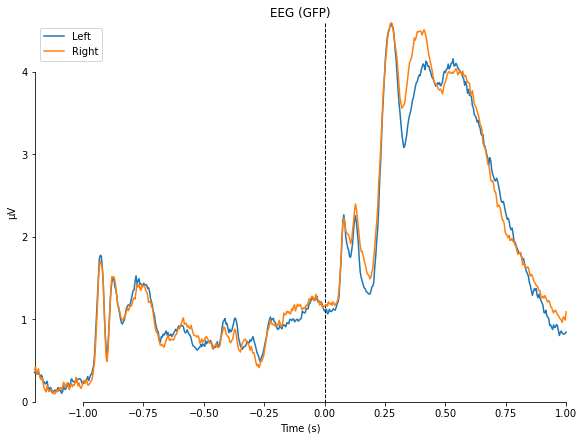

[<Figure size 576x432 with 1 Axes>]

In [23]:
left_grand = mne.grand_average(left_all)
right_grand = mne.grand_average(right_all)

mne.viz.plot_compare_evokeds(
    {"Left": left_grand, "Right": right_grand},
    picks="eeg"
)

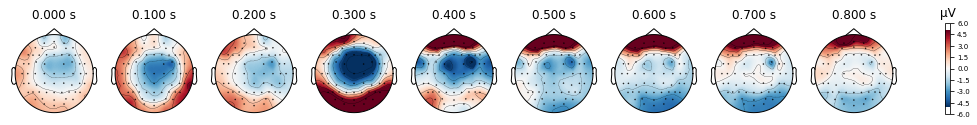

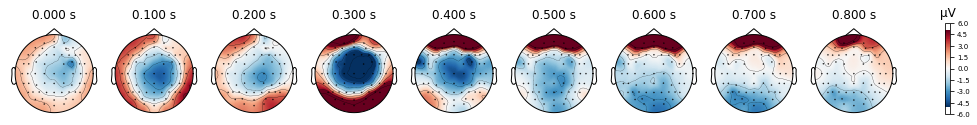

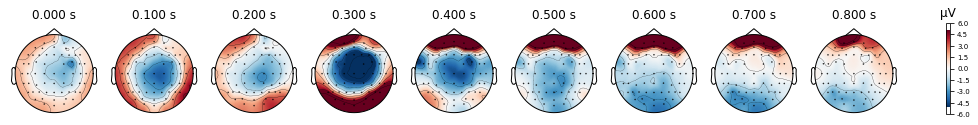

In [24]:
vlim = (-5, 5)

left_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)
right_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)

### ERPs for Mask x Side

In [25]:
import os
import mne
import numpy as np

left_short = []
right_short = []
left_long = []
right_long = []

subjects = [0,1,2,3,4,5]
tmin, tmax = -1.2, 1.0
baseline = (-1.2, -1.0)
highpass = 0.1
lowpass = 100


for sub in subjects:

    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "eeg", folder_name)
    files = os.listdir(sub_folder)

    vhdrs = [x for x in files if ".vhdr" in x]
    raw = []
    allowed_events = get_main_events()
    rename_dict = condition_events(allowed_events=allowed_events,  rename_cond="side/mask")

    for vhdr in vhdrs:
        vhdr_file = os.path.join(sub_folder, vhdr)
        raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

    raw = mne.concatenate_raws(raw)

    raw.annotations.rename(rename_dict)
    raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
    raw = raw.resample(250)
    raw.set_channel_types({
    'VEOG1':'eog',
    'VEOG2':'eog',
    'HEOG1':'eog',
    'HEOG2':'eog'
})
    raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg')

    events, events_ids = mne.events_from_annotations(raw)
    events = events[2:, :]

    condition_keys = list(set(rename_dict.values()))
    event_dict = {ck: events_ids[ck] for ck in condition_keys}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_dict,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True
    )

    montage = mne.channels.make_standard_montage('easycap-M1')
    epochs.set_montage(montage)

    # subject averages
    left_short.append(epochs["Left/Short"].average())
    right_short.append(epochs["Right/Short"].average())
    left_long.append(epochs["Left/Long"].average())
    right_long.append(epochs["Right/Long"].average())

Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_00_0000.vhdr...
Setting channel info structure...
Reading 0 ... 928519  =      0.000 ...   928.519 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_01_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1437719  =      0.000 ...  1437.719 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_02_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1322359  =      0.000 ...  1322.359 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0000/MaskExpatt_03_0000.vhdr...
Setting channel info structure...
Reading 0 ... 1205659  =      0.000 ...  1205.659 secs...
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 0.1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.7s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1173 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1173 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_00_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1356679  =      0.000 ...  1356.679 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001/MaskExpatt_01_0001.vhdr...
Setting channel info structure...
Reading 0 ... 1509659  =      0.000 ...  1509.659 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0001

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    4.1s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/ControlBox is not connected via USB', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_00_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1585979  =      0.000 ...  1585.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_01_0002.vhdr...
Setting channel info structure...
Reading 0 ... 1452319  =      0.000 ...  1452.319 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0002/Mask_ExpAtt_02

...

Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_00_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1407979  =      0.000 ...  1407.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_01_0004.vhdr...
Setting channel info structure...
Reading 0 ... 1460939  =      0.000 ...  1460.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0004/Mask_ExpAtt_02_0004.v

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.6s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_00_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1472979  =      0.000 ...  1472.979 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask_ExpAtt_01_0005.vhdr...
Setting channel info structure...
Reading 0 ... 1447939  =      0.000 ...  1447.939 secs...
Extracting parameters from /projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG/eeg/sub-0005/Mask

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    3.5s finished


Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: ['Comment/no USB Connection to actiCAP', 'Left/Long', 'Left/Short', 'New Segment/', 'Right/Long', 'Right/Short', 'Stimulus/S  1', 'Stimulus/S  5', 'Stimulus/S 99']
Not setting metadata
1280 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 1280 events and 551 original time points ...
0 bad epochs dropped


Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


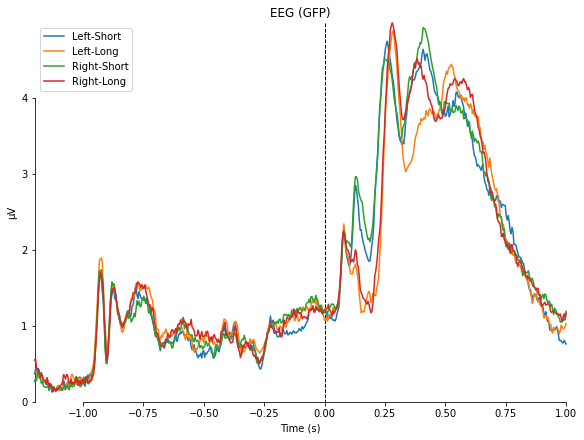

[<Figure size 576x432 with 1 Axes>]

In [26]:
left_short_grand = mne.grand_average(left_short)
right_short_grand = mne.grand_average(right_short)
left_long_grand = mne.grand_average(left_long)
right_long_grand = mne.grand_average(right_long)

mne.viz.plot_compare_evokeds(
    {"Left-Short": left_short_grand, "Left-Long": left_long_grand,
    "Right-Short": right_short_grand, "Right-Long": right_long_grand},
    picks="eeg")
    
    

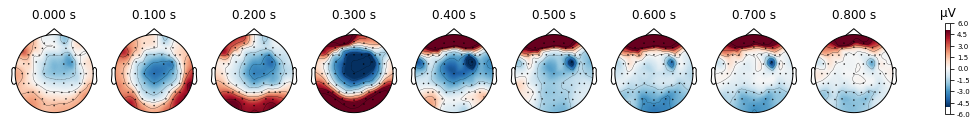

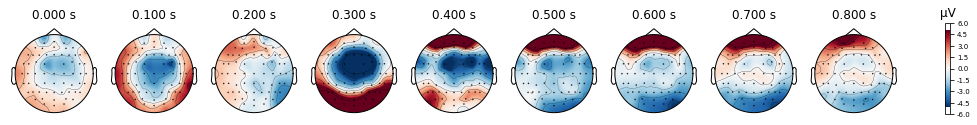

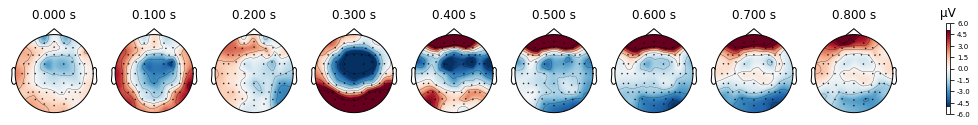

In [27]:
vlim = (-5, 5)

left_short_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)
left_long_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)

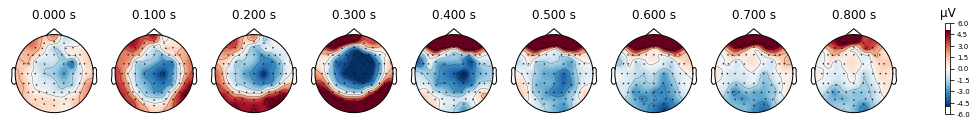

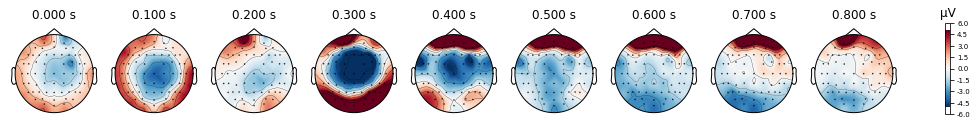

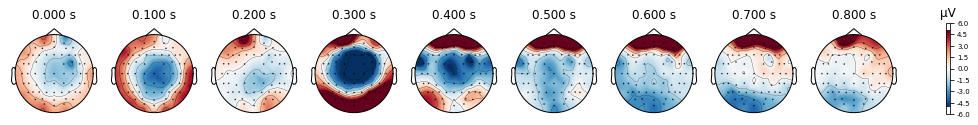

In [29]:
right_short_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)
right_long_grand.plot_topomap(times=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8], vlim=vlim)

In [4]:
import os
import mne
import numpy as np

subjects = [0,1,2,3,4,5]
# I don't want to see all the output
mne.set_log_level('error')

left_short_neutral = []
right_short_neutral = []
left_long_neutral = []
right_long_neutral = []


left_short_expected = []
right_short_expected = []
left_long_expected = []
right_long_expected = []

left_short_unexpected = []
right_short_unexpected = []
left_long_unexpected = []
right_long_unexpected = []

subjects = [0,1,2,3,4,5]
tmin, tmax = -1.2, 1.0
baseline = (-1.2, -1.0)
highpass = 0.1
lowpass = 100


for sub in subjects:

    folder_name = f"sub-{sub:04d}"
    sub_folder = os.path.join(PATH, "eeg", folder_name)
    files = os.listdir(sub_folder)

    vhdrs = [x for x in files if ".vhdr" in x]
    raw = []
    allowed_events = get_main_events()
    rename_dict = condition_events(allowed_events=allowed_events,  rename_cond="side/mask/cue")

    for vhdr in vhdrs:
        vhdr_file = os.path.join(sub_folder, vhdr)
        raw.append(mne.io.read_raw_brainvision(vhdr_file, preload=True))

    raw = mne.concatenate_raws(raw)
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    raw.annotations.rename(rename_dict)
    raw = raw.filter(l_freq=highpass, h_freq=lowpass, picks=eeg_picks)
    raw = raw.resample(250)
    raw.set_channel_types({
    'VEOG1':'eog',
    'VEOG2':'eog',
    'HEOG1':'eog',
    'HEOG2':'eog'
})
    raw, _ = mne.set_eeg_reference(raw, ref_channels='average', ch_type = 'eeg')

    events, events_ids = mne.events_from_annotations(raw)
    events = events[2:, :]

    condition_keys = list(set(rename_dict.values()))
    event_dict = {ck: events_ids[ck] for ck in condition_keys}

    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_dict,
        tmin=tmin,
        tmax=tmax,
        baseline=baseline,
        preload=True
    )

    montage = mne.channels.make_standard_montage('easycap-M1')
    epochs.set_montage(montage)

    # subject averages
    left_short_neutral.append(epochs["Left/Short/Neutral"].average())
    right_short_neutral.append(epochs["Right/Short/Neutral"].average())
    left_long_neutral.append(epochs["Left/Long/Neutral"].average())
    right_long_neutral.append(epochs["Right/Long/Neutral"].average())
    
    # expected
    left_short_expected.append(epochs["Left/Short/Expected"].average())
    right_short_expected.append(epochs["Right/Short/Expected"].average())
    left_long_expected.append(epochs["Left/Long/Expected"].average())
    right_long_expected.append(epochs["Right/Long/Expected"].average())

    # unexpected
    left_short_unexpected.append(epochs["Left/Short/Unexpected"].average())
    right_short_unexpected.append(epochs["Right/Short/Unexpected"].average())
    left_long_unexpected.append(epochs["Left/Long/Unexpected"].average())
    right_long_unexpected.append(epochs["Right/Long/Unexpected"].average())

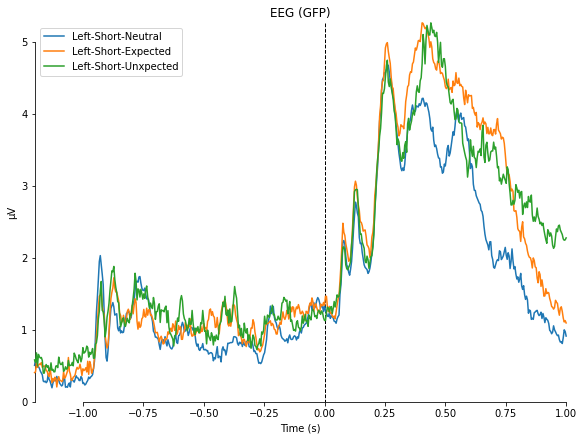

[<Figure size 576x432 with 1 Axes>]

In [5]:
left_short_neutral_grand = mne.grand_average(left_short_neutral)
left_short_expected_grand = mne.grand_average(left_short_expected)
left_short_unexpected_grand = mne.grand_average(left_short_unexpected)


mne.viz.plot_compare_evokeds(
    {"Left-Short-Neutral": left_short_neutral_grand, "Left-Short-Expected": left_short_expected_grand,
    "Left-Short-Unxpected": left_short_unexpected_grand},
    picks="eeg")
    

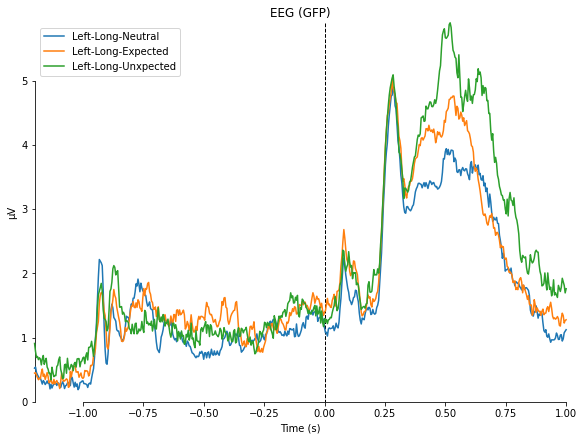

[<Figure size 576x432 with 1 Axes>]

In [6]:
left_long_neutral_grand = mne.grand_average(left_long_neutral)
left_long_expected_grand = mne.grand_average(left_long_expected)
left_long_unexpected_grand = mne.grand_average(left_long_unexpected)


mne.viz.plot_compare_evokeds(
    {"Left-Long-Neutral": left_long_neutral_grand, "Left-Long-Expected": left_long_expected_grand,
    "Left-Long-Unxpected": left_long_unexpected_grand},
    picks="eeg")

### First we need to do a left right partition regardless of cue or mask
- so from 48 ids we need to go down to 8 (4 left and 4 right)
- there would be 160 trials per image regarless of cue or mask 

#### Second we need to left/short, right/short, left/long, right/long regardless of cue
- so from 48 ids we need to go down to 16 
- there would be 80 trials per image per side per mask 

#### Third we need to do left/short/neutral/animal vs left/short/neutral/object etc
- so from 48 ids we need to go down to 24
- there would be 80 trials for neutral // 56 for expected // 24 for unexpected 


### Standard Decoding

In [5]:
import numpy as np
from tqdm import tqdm 
from MaskExp.data_helpers import *
from ExpAtt.data_helpers import load_data
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import * 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"
CLASSIFIER = LinearDiscriminantAnalysis()
CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

for decoding_partition in ["side/mask/cue-category"]:
    for sub in [0,1,2,3,4,5]:
    
        testsize = 0.2
        group_size = 2
        whitening = True
        imgPerm = 1


        all_events = get_main_events()
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}.pickle")
        subject_data = load_data(subject_path)
        ids_ = subject_data["ids"]
        eeg_ = subject_data["eeg"]

        # apply mapping
        rename_dict = condition_events_decoding(rename_cond = decoding_partition)
        ids_ = np.array([rename_dict[i] for i in ids_])

        # sort eeg and create pseudotrials 
        unique_, counts_ = np.unique(ids_, return_counts=True)

        if decoding_partition != 'side/mask/cue-category':
            min_trials = counts_.min()
            sorted_eeg = sort_eeg(eeg_, ids_, min_trials=min_trials)
            pstrials, pk = pseudotrials_general(sorted_eeg)
            
        else:
            segments = [
                ("neutral",    slice(0, 8)),
                ("expected",   slice(8, 16)),
                ("unexpected", slice(16, None)),
            ]

            results = {}
            for name, seg in segments:
                min_trials = counts_[seg].min()
                seg_ids    = ids_[np.isin(ids_, unique_[seg])]
                results[name] = sort_eeg(eeg_[np.isin(ids_, unique_[seg])], seg_ids, min_trials=min_trials)

            # Unpack if you need named variables
            sorted_neutral    = results["neutral"]
            pstrials_expected   = results["expected"]
            pstrials_unexpected = results["unexpected"]

            # pseudotrials only ran on neutral in the original — keep that explicit
            pstrials, pk = pseudotrials_general(sorted_neutral)
            

        ### Cross-validation params
        n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
        n_test = int(n_pstrials * testsize)
        cvs = int(n_pstrials / n_test)
        ps_ixs = np.arange(n_pstrials)

        ### Store variable
        decAcc = np.full((n_conditions, n_conditions, n_time, n_time), np.nan)
        indexes = np.arange(0, n_conditions)

        ### Cross-validation loop
        for cv in tqdm(range(cvs), desc="Cross-Validation", leave=False):
            
            test_ix = np.arange(n_test) + (cv * n_test)
            train_ix = np.delete(ps_ixs.copy(), test_ix)

            ps_train = pstrials[:, train_ix, :, :]
            ps_test = pstrials[:, test_ix, :, :]


            ### Pairwise loop
            for start in range(0, n_conditions, group_size):
                group = indexes[start:start + group_size]
                
                ### MVNN according to Guggenmos 
                if whitening:
                    ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
                else:
                    ps_train_w, ps_test_w = ps_train[group], ps_test[group]
                
                for i, cA in enumerate(group):
                    for cB in group[i + 1:]:                
                        for t in range(n_time):
                            train_x = np.array((ps_train_w[cA % group_size, :, :, t], ps_train_w[cB % group_size, :, :, t]))
                            train_x = np.reshape(train_x, (len(train_ix) * 2, n_sensors))

                            test_x = np.array((ps_test_w[cA % group_size], ps_test_w[cB % group_size]))
                            test_x = np.reshape(test_x, (len(test_ix) * 2, n_sensors, n_time))

                            train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))
                            test_y = np.array([1] * len(test_ix) + [2] * len(test_ix))

                            classifier = CLASSIFIER
                            classifier.fit(train_x, train_y)

                            ### Temporal Generalization
                            #for tt in range(n_time):
                            tt = t
                            pred_y = classifier.predict(test_x[:, :, tt])
                            acc_score = accuracy_score(test_y, pred_y)
                            decAcc[cA, cB, t, tt] = np.nansum(np.array((decAcc[cA, cB, t, tt], acc_score)))

        ### Normalize 
        decAcc = decAcc / (cvs * imgPerm)

        ### Save
        dec_part = decoding_partition.replace("/", "_")
        save_path = os.path.join(PATH, "eeg_decoding", f"eeg_decoding_{sub:04d}_{dec_part}.npy")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        np.save(save_path, decAcc)    


In [1]:
import numpy as np
from tqdm import tqdm 
from MaskExp.data_helpers import *
from ExpAtt.data_helpers import load_data
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import * 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"
CLASSIFIER = LinearDiscriminantAnalysis()
CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

for decoding_partition in ["mask/cue-category"]:
    for sub in [0,1,2,3,4,5]:
    
        testsize = 0.2
        group_size = 2
        whitening = True
        imgPerm = 1


        all_events = get_main_events()
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}.pickle")
        subject_data = load_data(subject_path)
        ids_ = subject_data["ids"]
        eeg_ = subject_data["eeg"]

        # apply mapping
        rename_dict = condition_events_decoding(rename_cond = decoding_partition)
        ids_ = np.array([rename_dict[i] for i in ids_])

Conditions: 100%|██████████| 2/2 [00:00<00:00, 184.36it/s]


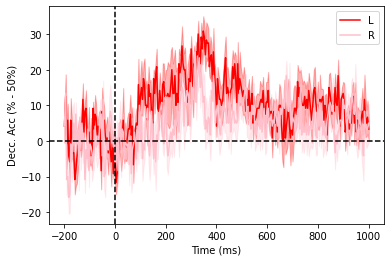

In [8]:
import matplotlib.pyplot as plt
condition_colors = ["red", "pink"]
condition_names = ["L", "R"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side" in x and "mask" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)
time =  np.linspace(-200, 1001, n_time).astype(int)


anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(2), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((8), False)
    log_arr[start:end] = True
    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]
    # average every 2 points

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc
        
    decAcc = np.nanmean(decAcc, axis=0)
    plt.plot(time, decAcc, color=condition_colors[i], label=condition_names[i], linewidth=1.5)
    plt.fill_between(time, decAcc - decSem, decAcc + decSem, color=condition_colors[i], alpha=0.3)
        
plt.axhline(0, linestyle="--", c="k")
plt.ylabel("Decc. Acc (% - 50%)")
plt.xlabel("Time (ms)")
plt.axvline(0, linestyle="--", c="k")
plt.legend()

Conditions: 100%|██████████| 4/4 [00:00<00:00, 579.84it/s]


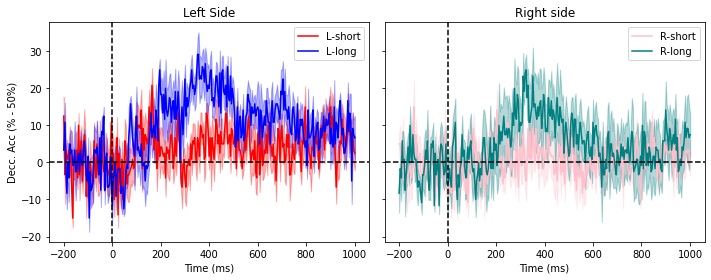

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short", "R-short", "L-long", "R-long"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask" in x and "cue" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)
time =  np.linspace(-200, 1001, n_time).astype(int)

# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((16), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side")
axes[1].set_title("Right side")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()

Text(0.5, 1.0, 'Mask')

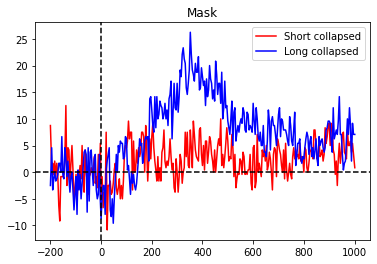

In [17]:
import numpy as np
long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Mask")

Conditions: 100%|██████████| 4/4 [00:00<00:00, 684.03it/s]


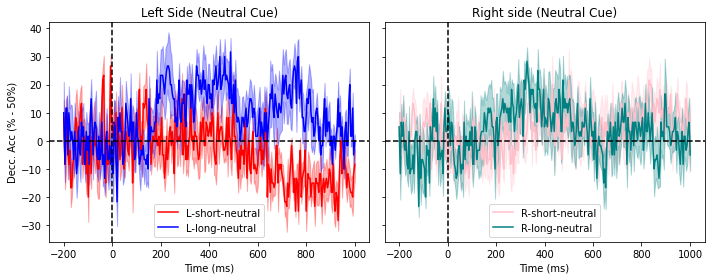

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short-neutral", "R-short-neutral", "L-long-neutral", "R-long-neutral"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask_cue" in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)
time =  np.linspace(-200, 1001, n_time).astype(int)

# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 2, (i + 1) * 2
    log_arr = np.full((8), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side (Neutral Cue)")
axes[1].set_title("Right side (Neutral Cue)")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()

Text(0.5, 1.0, 'Neutral Cue')

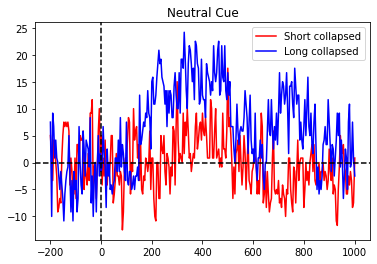

In [15]:
import numpy as np
long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Neutral Cue")

### Binning time points decoding (average window)

In [6]:
import numpy as np
from tqdm import tqdm 
from MaskExp.data_helpers import *
from ExpAtt.data_helpers import load_data
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import * 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"
CLASSIFIER = LinearDiscriminantAnalysis()
CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

for decoding_partition in ["side", "side/mask", "side/mask/cue-category"]:
    for sub in [0,1,2,3,4,5]:
    
        testsize = 0.2
        group_size = 2
        whitening = True
        imgPerm = 1
        window_size = 5
        stride = 5


        all_events = get_main_events()
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}.pickle")
        subject_data = load_data(subject_path)
        ids_ = subject_data["ids"]
        eeg_ = subject_data["eeg"]

        # apply mapping
        rename_dict = condition_events_decoding(rename_cond = decoding_partition)
        ids_ = np.array([rename_dict[i] for i in ids_])

        # sort eeg and create pseudotrials 
        unique_, counts_ = np.unique(ids_, return_counts=True)

        if decoding_partition != 'side/mask/cue-category':
            min_trials = counts_.min()
            sorted_eeg = sort_eeg(eeg_, ids_, min_trials=min_trials)
            pstrials, pk = pseudotrials_general(sorted_eeg)
            
        else:
            segments = [
                ("neutral",    slice(0, 8)),
                ("expected",   slice(8, 16)),
                ("unexpected", slice(16, None)),
            ]

            results = {}
            for name, seg in segments:
                min_trials = counts_[seg].min()
                seg_ids    = ids_[np.isin(ids_, unique_[seg])]
                results[name] = sort_eeg(eeg_[np.isin(ids_, unique_[seg])], seg_ids, min_trials=min_trials)

            # Unpack if you need named variables
            sorted_neutral    = results["neutral"]
            pstrials_expected   = results["expected"]
            pstrials_unexpected = results["unexpected"]

            # pseudotrials only ran on neutral in the original — keep that explicit
            pstrials, pk = pseudotrials_general(sorted_neutral)
            

        ### Cross-validation params
        n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
        n_windows = (n_time - window_size) // stride + 1
        n_test = int(n_pstrials * testsize)
        cvs = int(n_pstrials / n_test)
        ps_ixs = np.arange(n_pstrials)

        ### Store variable
        decAcc = np.full((n_conditions, n_conditions, n_windows, n_windows), np.nan)
        indexes = np.arange(0, n_conditions)

        ### Cross-validation loop
        for cv in tqdm(range(cvs), desc="Cross-Validation", leave=False):
            
            test_ix = np.arange(n_test) + (cv * n_test)
            train_ix = np.delete(ps_ixs.copy(), test_ix)

            ps_train = pstrials[:, train_ix, :, :]
            ps_test = pstrials[:, test_ix, :, :]


            ### Pairwise loop
            for start in range(0, n_conditions, group_size):
                group = indexes[start:start + group_size]
                
                ### MVNN according to Guggenmos 
                if whitening:
                    ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
                else:
                    ps_train_w, ps_test_w = ps_train[group], ps_test[group]
                
                for i, cA in enumerate(group):
                    for cB in group[i + 1:]:
                        for t in range(n_windows):
                            t_start = t * stride
                            t_end   = t_start + window_size

                            train_x = np.array([
                                ps_train_w[cA % group_size, :, :, t_start:t_end].mean(axis=-1),
                                ps_train_w[cB % group_size, :, :, t_start:t_end].mean(axis=-1),
                            ]).reshape(len(train_ix) * 2, n_sensors)

                            train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))
                            test_y  = np.array([1] * len(test_ix)  + [2] * len(test_ix))

                            classifier = CLASSIFIER
                            classifier.fit(train_x, train_y)

                            for tt in range(n_windows):
                                tt_start = tt * stride
                                tt_end   = tt_start + window_size

                                test_x = np.array([
                                    ps_test_w[cA % group_size, :, :, tt_start:tt_end].mean(axis=-1),
                                    ps_test_w[cB % group_size, :, :, tt_start:tt_end].mean(axis=-1),
                                ]).reshape(len(test_ix) * 2, n_sensors)

                                pred_y    = classifier.predict(test_x)
                                acc_score = accuracy_score(test_y, pred_y)
                                decAcc[cA, cB, t, tt] = np.nansum([decAcc[cA, cB, t, tt], acc_score])

        ### Normalize 
        decAcc = decAcc / (cvs * imgPerm)

        ### Save
        dec_part = decoding_partition.replace("/", "_")
        save_path = os.path.join(PATH, "eeg_decoding", f"eeg_decoding_{sub:04d}_{dec_part}.npy")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        np.save(save_path, decAcc)    

Conditions:   0%|          | 0/2 [00:00<?, ?it/s]

Conditions: 100%|██████████| 4/4 [00:00<00:00, 681.64it/s]


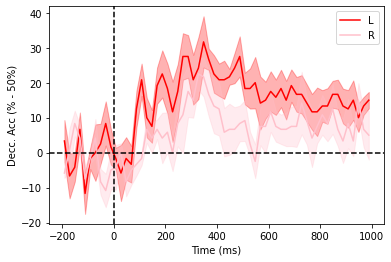

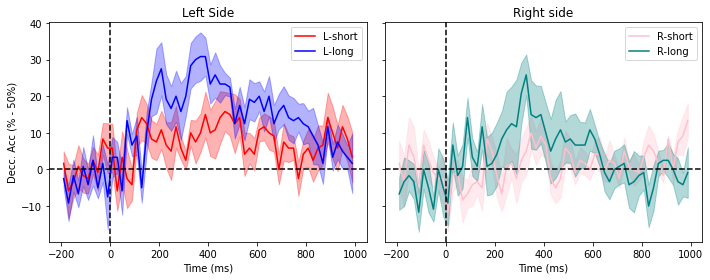

Conditions: 100%|██████████| 4/4 [00:00<00:00, 745.69it/s]


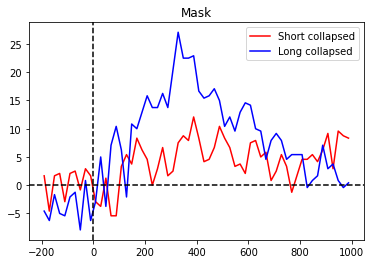

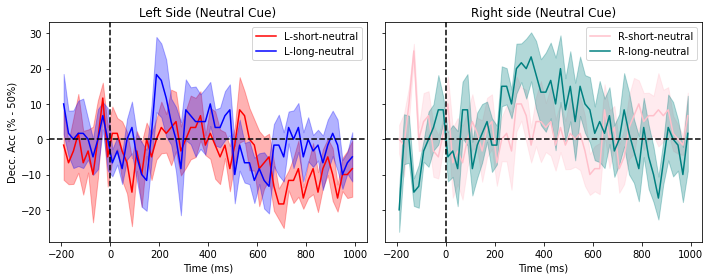

Text(0.5, 1.0, 'Neutral Cue')

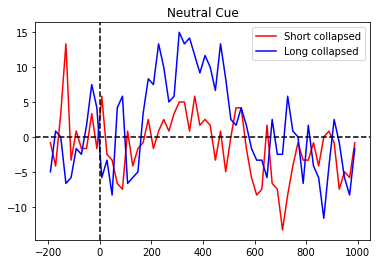

In [8]:
import matplotlib.pyplot as plt
orig_time = 301
time_points = np.linspace(-200, 1001, orig_time)
time = np.array([
    time_points[t * stride + window_size // 2] 
    for t in range(n_windows)
]).astype(int)


condition_colors = ["red", "pink"]
condition_names = ["L", "R"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side" in x and "mask" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(2), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((8), False)
    log_arr[start:end] = True
    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]
    # average every 2 points

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc
        
    decAcc = np.nanmean(decAcc, axis=0)
    plt.plot(time, decAcc, color=condition_colors[i], label=condition_names[i], linewidth=1.5)
    plt.fill_between(time, decAcc - decSem, decAcc + decSem, color=condition_colors[i], alpha=0.3)
        
plt.axhline(0, linestyle="--", c="k")
plt.ylabel("Decc. Acc (% - 50%)")
plt.xlabel("Time (ms)")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short", "R-short", "L-long", "R-long"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask" in x and "cue" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)

# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((16), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side")
axes[1].set_title("Right side")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()


long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Mask")
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short-neutral", "R-short-neutral", "L-long-neutral", "R-long-neutral"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask_cue" in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)


# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 2, (i + 1) * 2
    log_arr = np.full((8), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side (Neutral Cue)")
axes[1].set_title("Right side (Neutral Cue)")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()

long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Neutral Cue")

### Binning time points decoding (flatten window)

In [9]:
import numpy as np
from tqdm import tqdm 
from MaskExp.data_helpers import *
from ExpAtt.data_helpers import load_data
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import * 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"
CLASSIFIER = LinearDiscriminantAnalysis()
CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

for decoding_partition in ["side", "side/mask", "side/mask/cue-category"]:
    for sub in [0,1,2,3,4,5]:
    
        testsize = 0.2
        group_size = 2
        whitening = True
        imgPerm = 1
        window_size = 5
        stride = 5


        all_events = get_main_events()
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}.pickle")
        subject_data = load_data(subject_path)
        ids_ = subject_data["ids"]
        eeg_ = subject_data["eeg"]

        # apply mapping
        rename_dict = condition_events_decoding(rename_cond = decoding_partition)
        ids_ = np.array([rename_dict[i] for i in ids_])

        # sort eeg and create pseudotrials 
        unique_, counts_ = np.unique(ids_, return_counts=True)

        if decoding_partition != 'side/mask/cue-category':
            min_trials = counts_.min()
            sorted_eeg = sort_eeg(eeg_, ids_, min_trials=min_trials)
            pstrials, pk = pseudotrials_general(sorted_eeg)
            
        else:
            segments = [
                ("neutral",    slice(0, 8)),
                ("expected",   slice(8, 16)),
                ("unexpected", slice(16, None)),
            ]

            results = {}
            for name, seg in segments:
                min_trials = counts_[seg].min()
                seg_ids    = ids_[np.isin(ids_, unique_[seg])]
                results[name] = sort_eeg(eeg_[np.isin(ids_, unique_[seg])], seg_ids, min_trials=min_trials)

            # Unpack if you need named variables
            sorted_neutral    = results["neutral"]
            pstrials_expected   = results["expected"]
            pstrials_unexpected = results["unexpected"]

            # pseudotrials only ran on neutral in the original — keep that explicit
            pstrials, pk = pseudotrials_general(sorted_neutral)
            

        ### Cross-validation params
        n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
        n_windows = (n_time - window_size) // stride + 1
        n_test = int(n_pstrials * testsize)
        cvs = int(n_pstrials / n_test)
        ps_ixs = np.arange(n_pstrials)

        ### Store variable
        decAcc = np.full((n_conditions, n_conditions, n_windows, n_windows), np.nan)
        indexes = np.arange(0, n_conditions)

        ### Cross-validation loop
        for cv in tqdm(range(cvs), desc="Cross-Validation", leave=False):
            
            test_ix = np.arange(n_test) + (cv * n_test)
            train_ix = np.delete(ps_ixs.copy(), test_ix)

            ps_train = pstrials[:, train_ix, :, :]
            ps_test = pstrials[:, test_ix, :, :]


            ### Pairwise loop
            for start in range(0, n_conditions, group_size):
                group = indexes[start:start + group_size]
                
                ### MVNN according to Guggenmos 
                if whitening:
                    ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
                else:
                    ps_train_w, ps_test_w = ps_train[group], ps_test[group]
                
                for i, cA in enumerate(group):
                    for cB in group[i + 1:]:
                        for t in range(n_windows):
                            t_start = t * stride
                            t_end   = t_start + window_size

                            train_x = np.array([
                                ps_train_w[cA % group_size, :, :, t_start:t_end].reshape(len(train_ix), n_sensors * window_size),
                                ps_train_w[cB % group_size, :, :, t_start:t_end].reshape(len(train_ix), n_sensors * window_size),
                            ]).reshape(len(train_ix) * 2, n_sensors * window_size)

                            train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))
                            test_y  = np.array([1] * len(test_ix)  + [2] * len(test_ix))

                            classifier = CLASSIFIER
                            classifier.fit(train_x, train_y)

                            for tt in range(n_windows):
                                tt_start = tt * stride
                                tt_end   = tt_start + window_size

                                test_x = np.array([
                                    ps_test_w[cA % group_size, :, :, tt_start:tt_end].reshape(len(test_ix), n_sensors * window_size),
                                    ps_test_w[cB % group_size, :, :, tt_start:tt_end].reshape(len(test_ix), n_sensors * window_size),
                                ]).reshape(len(test_ix) * 2, n_sensors * window_size)

                                pred_y    = classifier.predict(test_x)
                                acc_score = accuracy_score(test_y, pred_y)
                                decAcc[cA, cB, t, tt] = np.nansum([decAcc[cA, cB, t, tt], acc_score])

        ### Normalize 
        decAcc = decAcc / (cvs * imgPerm)

        ### Save
        dec_part = decoding_partition.replace("/", "_")
        save_path = os.path.join(PATH, "eeg_decoding", f"eeg_decoding_{sub:04d}_{dec_part}.npy")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        np.save(save_path, decAcc)  

Conditions: 100%|██████████| 4/4 [00:00<00:00, 719.10it/s]


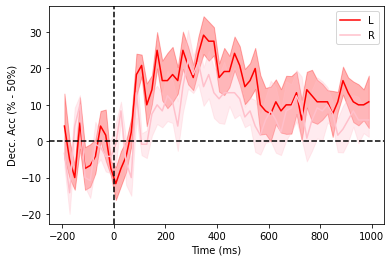

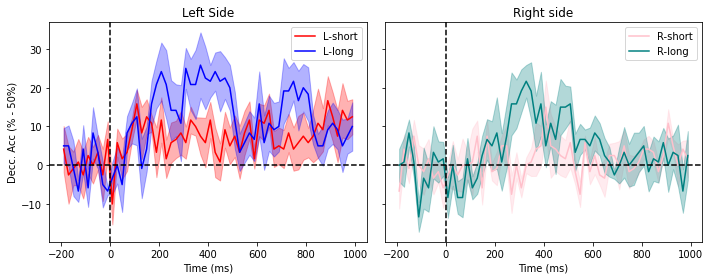

Conditions: 100%|██████████| 4/4 [00:00<00:00, 621.63it/s]


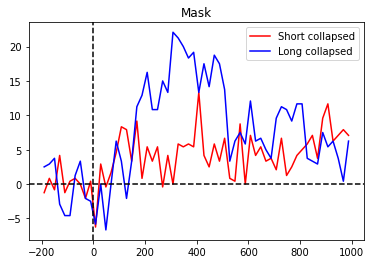

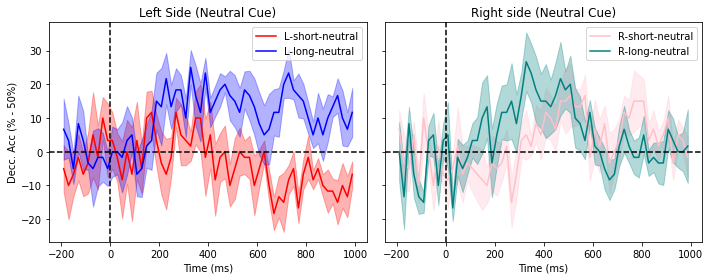

Text(0.5, 1.0, 'Neutral Cue')

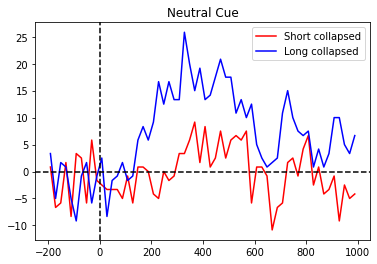

In [10]:
import matplotlib.pyplot as plt
orig_time = 301
time_points = np.linspace(-200, 1001, orig_time)
time = np.array([
    time_points[t * stride + window_size // 2] 
    for t in range(n_windows)
]).astype(int)


condition_colors = ["red", "pink"]
condition_names = ["L", "R"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side" in x and "mask" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(2), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((8), False)
    log_arr[start:end] = True
    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]
    # average every 2 points

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc
        
    decAcc = np.nanmean(decAcc, axis=0)
    plt.plot(time, decAcc, color=condition_colors[i], label=condition_names[i], linewidth=1.5)
    plt.fill_between(time, decAcc - decSem, decAcc + decSem, color=condition_colors[i], alpha=0.3)
        
plt.axhline(0, linestyle="--", c="k")
plt.ylabel("Decc. Acc (% - 50%)")
plt.xlabel("Time (ms)")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short", "R-short", "L-long", "R-long"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask" in x and "cue" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)

# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((16), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side")
axes[1].set_title("Right side")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()


long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Mask")
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short-neutral", "R-short-neutral", "L-long-neutral", "R-long-neutral"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask_cue" in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)


# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 2, (i + 1) * 2
    log_arr = np.full((8), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side (Neutral Cue)")
axes[1].set_title("Right side (Neutral Cue)")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()

long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Neutral Cue")

### Binning time points decoding (flatten window + vis cluster)

In [15]:
import numpy as np
from tqdm import tqdm 
from MaskExp.data_helpers import *
from ExpAtt.data_helpers import load_data
from ExpAtt.decoding_pstrials import pseudotrials_general
from ExpAtt.decoding_mvnn import * 

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score


PATH = "/projects/archiv/DataStore_Boyanova/Mask_ExpAtt_EEG"
CLASSIFIER = LinearDiscriminantAnalysis()
CLASSIFIER = LinearSVC(dual=True, penalty='l2', loss='hinge', C=1.0, max_iter=10000)

for decoding_partition in ["side", "side/mask", "side/mask/cue-category"]:
    for sub in [0,1,2,3,4,5]:
    
        testsize = 0.2
        group_size = 2
        whitening = True
        imgPerm = 1
        window_size = 5
        stride = 5


        all_events = get_main_events()
        subject_path = os.path.join(PATH, "eeg_epoched",  f"eeg_MaskExp_{sub:04d}.pickle")
        subject_data = load_data(subject_path)
        ids_ = subject_data["ids"]
        eeg_ = subject_data["eeg"]
        channels = subject_data["channels"]
        roi_channels = [ch for ch in channels if ch.startswith('O') or ch.startswith('PO')]
        roi_ix = [channels.index(ch) for ch in roi_channels]

        # apply mapping
        rename_dict = condition_events_decoding(rename_cond = decoding_partition)
        ids_ = np.array([rename_dict[i] for i in ids_])

        # sort eeg and create pseudotrials 
        unique_, counts_ = np.unique(ids_, return_counts=True)

        if decoding_partition != 'side/mask/cue-category':
            min_trials = counts_.min()
            sorted_eeg = sort_eeg(eeg_, ids_, min_trials=min_trials)
            pstrials, pk = pseudotrials_general(sorted_eeg)
            
        else:
            segments = [
                ("neutral",    slice(0, 8)),
                ("expected",   slice(8, 16)),
                ("unexpected", slice(16, None)),
            ]

            results = {}
            for name, seg in segments:
                min_trials = counts_[seg].min()
                seg_ids    = ids_[np.isin(ids_, unique_[seg])]
                results[name] = sort_eeg(eeg_[np.isin(ids_, unique_[seg])], seg_ids, min_trials=min_trials)

            # Unpack if you need named variables
            sorted_neutral    = results["neutral"]
            pstrials_expected   = results["expected"]
            pstrials_unexpected = results["unexpected"]

            # pseudotrials only ran on neutral in the original — keep that explicit
            pstrials, pk = pseudotrials_general(sorted_neutral)
            

        ### Cross-validation params
        n_conditions, n_pstrials, n_sensors, n_time = pstrials.shape
        n_windows = (n_time - window_size) // stride + 1
        n_test = int(n_pstrials * testsize)
        cvs = int(n_pstrials / n_test)
        ps_ixs = np.arange(n_pstrials)
        n_sensors_roi = len(roi_ix)

        ### Store variable
        decAcc = np.full((n_conditions, n_conditions, n_windows, n_windows), np.nan)
        indexes = np.arange(0, n_conditions)

        ### Cross-validation loop
        for cv in tqdm(range(cvs), desc="Cross-Validation", leave=False):
            
            test_ix = np.arange(n_test) + (cv * n_test)
            train_ix = np.delete(ps_ixs.copy(), test_ix)

            ps_train = pstrials[:, train_ix, :, :]
            ps_test = pstrials[:, test_ix, :, :]

            ### Pairwise loop
            for start in range(0, n_conditions, group_size):
                group = indexes[start:start + group_size]
                
                ### MVNN according to Guggenmos 
                if whitening:
                    ps_train_w, ps_test_w = mvnn(ps_train[group], ps_test[group], group_size, n_sensors, n_time)
                else:
                    ps_train_w, ps_test_w = ps_train[group], ps_test[group]
                
                # Slice to ROI channels after whitening
                ps_train_w = ps_train_w[:, :, roi_ix, :]
                ps_test_w  = ps_test_w[:, :, roi_ix, :]
                
                for i, cA in enumerate(group):
                    for cB in group[i + 1:]:
                        for t in range(n_windows):
                            t_start = t * stride
                            t_end   = t_start + window_size
                            train_x = np.array([
                                ps_train_w[cA % group_size, :, :, t_start:t_end].reshape(len(train_ix), n_sensors_roi * window_size),
                                ps_train_w[cB % group_size, :, :, t_start:t_end].reshape(len(train_ix), n_sensors_roi * window_size),
                            ]).reshape(len(train_ix) * 2, n_sensors_roi * window_size)

                            train_y = np.array([1] * len(train_ix) + [2] * len(train_ix))
                            test_y  = np.array([1] * len(test_ix)  + [2] * len(test_ix))

                            classifier = CLASSIFIER
                            classifier.fit(train_x, train_y)

                            for tt in range(n_windows):
                                tt_start = tt * stride
                                tt_end   = tt_start + window_size
                                test_x = np.array([
                                    ps_test_w[cA % group_size, :, :, tt_start:tt_end].reshape(len(test_ix), n_sensors_roi * window_size),
                                    ps_test_w[cB % group_size, :, :, tt_start:tt_end].reshape(len(test_ix), n_sensors_roi * window_size),
                                ]).reshape(len(test_ix) * 2, n_sensors_roi * window_size)

                                pred_y    = classifier.predict(test_x)
                                acc_score = accuracy_score(test_y, pred_y)
                                decAcc[cA, cB, t, tt] = np.nansum([decAcc[cA, cB, t, tt], acc_score])

        ### Normalize 
        decAcc = decAcc / (cvs * imgPerm)

        ### Save
        dec_part = decoding_partition.replace("/", "_")
        save_path = os.path.join(PATH, "eeg_decoding", f"eeg_decoding_{sub:04d}_{dec_part}.npy")
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        np.save(save_path, decAcc)  

Conditions: 100%|██████████| 4/4 [00:00<00:00, 620.92it/s]


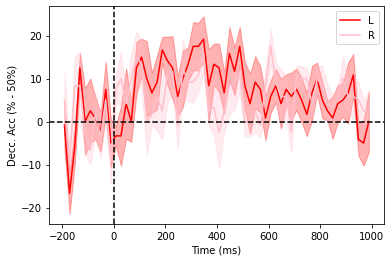

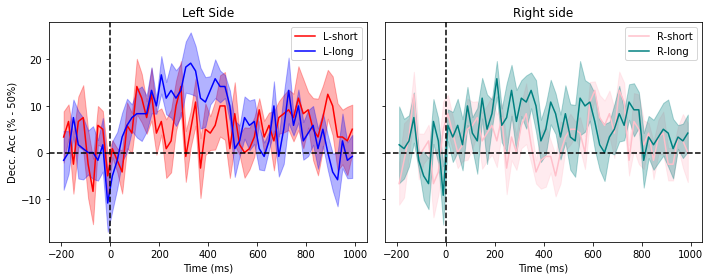

Conditions: 100%|██████████| 4/4 [00:00<00:00, 737.14it/s]


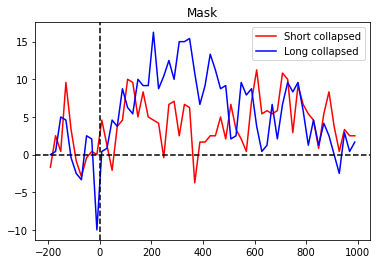

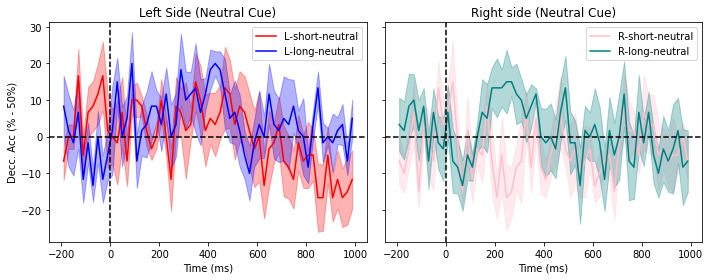

Text(0.5, 1.0, 'Neutral Cue')

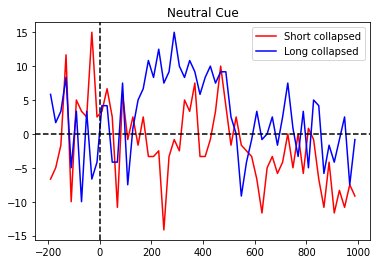

In [16]:
import matplotlib.pyplot as plt
orig_time = 301
time_points = np.linspace(-200, 1001, orig_time)
time = np.array([
    time_points[t * stride + window_size // 2] 
    for t in range(n_windows)
]).astype(int)


condition_colors = ["red", "pink"]
condition_names = ["L", "R"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side" in x and "mask" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(2), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((8), False)
    log_arr[start:end] = True
    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]
    # average every 2 points

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc
        
    decAcc = np.nanmean(decAcc, axis=0)
    plt.plot(time, decAcc, color=condition_colors[i], label=condition_names[i], linewidth=1.5)
    plt.fill_between(time, decAcc - decSem, decAcc + decSem, color=condition_colors[i], alpha=0.3)
        
plt.axhline(0, linestyle="--", c="k")
plt.ylabel("Decc. Acc (% - 50%)")
plt.xlabel("Time (ms)")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short", "R-short", "L-long", "R-long"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask" in x and "cue" not in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)

# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 4, (i + 1) * 4
    log_arr = np.full((16), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side")
axes[1].set_title("Right side")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()


long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Mask")
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
condition_colors = ["red", "pink", "blue", "teal"]
condition_names = ["L-short-neutral", "R-short-neutral", "L-long-neutral", "R-long-neutral"]
    
### Load data
target_dir = os.path.join(PATH, "eeg_decoding")
files = np.sort([x for x in os.listdir(target_dir)
                 if ".npy" in x and "side_mask_cue" in x])
data_array = np.array([np.load(os.path.join(target_dir, fname)) for fname in files]) 

### Normalize 
data_array = data_array * 100 - 50 # zeros down
n_subjects, n_imgs, _, n_time, _ = data_array.shape
data_array = data_array[:, :, :, np.arange(n_time), np.arange(n_time)] # get only diagonal 
img_indexes = np.arange(0, n_imgs)


# mapping conditions → subplot
# 0,2 → left (index 0); 1,3 → right (index 1)
plot_map = {0: 0, 2: 0, 1: 1, 3: 1}

anova_data  = np.full((n_subjects, 4, n_time), np.nan)

for i in tqdm(range(4), desc="Conditions"):
    start, end = i * 2, (i + 1) * 2
    log_arr = np.full((8), False)
    log_arr[start:end] = True

    cond_data = data_array[:, img_indexes[log_arr], :, :]
    cond_data = cond_data[:, :, img_indexes[log_arr]]

    decAcc = np.nanmean(cond_data, axis=(1,2))
    decSem = np.std(decAcc, axis=0) / np.sqrt(n_subjects)
    anova_data[:, i] = decAcc

    decAcc = np.nanmean(decAcc, axis=0)

    ax = axes[plot_map[i]]

    ax.plot(time, decAcc,
            color=condition_colors[i],
            label=condition_names[i],
            linewidth=1.5)

    ax.fill_between(time,
                    decAcc - decSem,
                    decAcc + decSem,
                    color=condition_colors[i],
                    alpha=0.3)

# titles
axes[0].set_title("Left Side (Neutral Cue)")
axes[1].set_title("Right side (Neutral Cue)")

axes[0].axhline(0, linestyle="--", c="k")
axes[0].axvline(0, linestyle="--", c="k")
axes[1].axhline(0, linestyle="--", c="k")
axes[1].axvline(0, linestyle="--", c="k")

# legends per subplot (cleaner)
axes[0].legend()
axes[0].set_ylabel("Decc. Acc (% - 50%)")
axes[0].set_xlabel("Time (ms)")
axes[1].set_xlabel("Time (ms)")
axes[1].legend()

plt.tight_layout()
plt.show()

long = np.nanmean(anova_data[:, 0:2, :], axis=(0,1))
short = np.nanmean(anova_data[:, 2:, :], axis=(0,1))

plt.plot(time, long, c="red", label="Short collapsed")
plt.plot(time, short, c="blue", label="Long collapsed")
plt.axhline(0, linestyle="--", c="k")
plt.axvline(0, linestyle="--", c="k")
plt.legend()
plt.title("Neutral Cue")